<a href="https://colab.research.google.com/github/YM1587/CKD-Risk-Regression-/blob/main/emergency_service.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ilkeryildiz/emergency-service-triage-application")

print("Path to dataset files:", path)

100%|██████████| 36.2k/36.2k [00:00<00:00, 51.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ilkeryildiz/emergency-service-triage-application/versions/2


In [ ]:
import os
import pandas as pd

# List contents of the downloaded directory
print("Files in dataset directory:")
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Files in dataset directory:
/root/.cache/kagglehub/datasets/ilkeryildiz/emergency-service-triage-application/versions/2/data.csv


In [ ]:
with open(data_file_path, 'r', encoding='latin1') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i == 9: # Print first 10 lines
            break

Group;Sex;Age;Patients number per hour;Arrival mode;Injury;Chief_complain;Mental;Pain;NRS_pain;SBP;DBP;HR;RR;BT;Saturation;KTAS_RN;Diagnosis in ED;Disposition;KTAS_expert;Error_group;Length of stay_min;KTAS duration_min;mistriage
2;2;71;3;3;2;right ocular pain;1;1;2;160;100;84;18;36.6;100;2;Corneal abrasion;1;4;2;86;5,00;1
1;1;56;12;3;2;right forearm burn;1;1;2;137;75;60;20;36.5;;4;Burn of hand, firts degree dorsum;1;5;4;64;3,95;1
2;1;68;8;2;2;arm pain, Lt;1;1;2;130;80;102;20;36.6;98;4;Fracture of surgical neck of humerus, closed;2;5;4;862;1,00;1
1;2;71;8;1;1;ascites tapping;1;1;3;139;94;88;20;36.5;;4;Alcoholic liver cirrhosis with ascites;1;5;6;108;9,83;1
1;2;58;4;3;1;distension, abd;1;1;3;91;67;93;18;36.5;;4;Ascites;1;5;8;109;6,60;1
2;1;54;6;4;1;fever;1;1;3;140;90;94;20;38.1;98;3;Fever, unspecified;2;4;1;9246;2,00;1
2;2;49;11;3;1;With chest discomfort;1;1;3;110;70;70;20;36.2;98;2;Angina pectoris, unspecified;1;3;2;400;3,00;1
1;2;78;14;3;1;pain, chest;1;1;3;169;86;80;20;36;;2;Acute co

Based on the file listing, I'll assume `emergency.csv` is the main dataset file. Let's load it into a pandas DataFrame.

In [ ]:
data_file_path = os.path.join(path, 'data.csv')
df = pd.read_csv(data_file_path, encoding='latin1', sep=';', decimal=',')

print("Dataset Head:")
display(df.head())

print("\nDataset Info:")
df.info()

Dataset Head:


,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,...,36.6,100,2,Corneal abrasion,1,4,2,86,5.00,1
1,1,1,56,12,3,2,right forearm burn,1,1,2,...,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,3.95,1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,...,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,1.00,1
3,1,2,71,8,1,1,ascites tapping,1,1,3,...,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,9.83,1
4,1,2,58,4,3,1,"distension, abd",1,1,3,...,36.5,NaN,4,Ascites,1,5,8,109,6.60,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Group                     1267 non-null   int64  
 1   Sex                       1267 non-null   int64  
 2   Age                       1267 non-null   int64  
 3   Patients number per hour  1267 non-null   int64  
 4   Arrival mode              1267 non-null   int64  
 5   Injury                    1267 non-null   int64  
 6   Chief_complain            1267 non-null   object 
 7   Mental                    1267 non-null   int64  
 8   Pain                      1267 non-null   int64  
 9   NRS_pain                  1267 non-null   object 
 10  SBP                       1267 non-null   object 
 11  DBP                       1267 non-null   object 
 12  HR                        1267 non-null   object 
 13  RR                        1267 non-null   object

### 1. Data Audit: Missing Values

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage (%)': missing_percentage})

print("Missing Values in Each Column:")
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False))

Missing Values in Each Column:


,Missing Count,Missing Percentage (%)
Saturation,688,54.301500
Diagnosis in ED,2,0.157853


### 2. Data Audit: Value Ranges and Unique Values for Object Columns

Let's inspect the 'object' type columns that appear to be numerical or categorical based on the `df.info()` output and the plan, to understand their content and identify issues like non-numeric entries or inconsistent formats.

In [ ]:
print("\n--- Column: Diagnosis in ED ---")
print(f"Unique values: {df['Diagnosis in ED'].nunique()}")
display(df['Diagnosis in ED'].value_counts(dropna=False).head(20)) # Display top 20 unique values, including NaNs


--- Column: Diagnosis in ED ---
Unique values: 583


,count
Diagnosis in ED,
Acute gastroenteritis,49
Headache,26
Unspecified abdominal pain,23
Ischaemic chest pain,21
"Open wound of other parts of head, face",20
Dizziness,20
Unstable angina,17
Dizziness and giddiness,15
"Gastrointestinal haemorrhage, unspecified",15


In [ ]:
object_columns = df.select_dtypes(include='object').columns

for col in object_columns:
    print(f"\n--- Column: {col} ---")
    print(f"Unique values: {df[col].nunique()}")
    display(df[col].value_counts(dropna=False).head(10)) # Display top 10 unique values


--- Column: Chief_complain ---
Unique values: 417


,count
Chief_complain,
abd pain,72
dyspnea,60
dizziness,59
fever,45
ant. chest pain,44
Open Wound,31
headache,30
mental change,22
epigastric pain,22



--- Column: Diagnosis in ED ---
Unique values: 583


,count
Diagnosis in ED,
Acute gastroenteritis,49
Headache,26
Unspecified abdominal pain,23
Ischaemic chest pain,21
"Open wound of other parts of head, face",20
Dizziness,20
Unstable angina,17
Dizziness and giddiness,15
"Gastrointestinal haemorrhage, unspecified",15


### 4. Clean Vital Signs and Pain Scale

Vital signs and pain scale columns are currently `object` type and contain non-numeric values. We need to convert them to numeric, coercing errors to `NaN`.

In [ ]:
import numpy as np

def clean_and_convert_to_numeric(df, column_name):
    """Cleans a column by replacing specific non-numeric strings with NaN and converting to numeric."""
    # Replace '#BOÞ!' specifically for 'NRS_pain' and potentially other non-numeric indicators
    if column_name == 'NRS_pain' and '#BOÞ!' in df[column_name].unique():
        df[column_name] = df[column_name].replace('#BOÞ!', np.nan)

    # Attempt to convert to numeric, coercing errors to NaN
    df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
    return df

# List of columns to clean and convert
columns_to_clean = ['NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation']

for col in columns_to_clean:
    df = clean_and_convert_to_numeric(df, col)

print("Data types after cleaning vital signs and NRS_pain:")
df.info()

print("\nFirst 5 rows after cleaning:")
display(df.head())

Data types after cleaning vital signs and NRS_pain:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Group                     1267 non-null   int64  
 1   Sex                       1267 non-null   int64  
 2   Age                       1267 non-null   int64  
 3   Patients number per hour  1267 non-null   int64  
 4   Arrival mode              1267 non-null   int64  
 5   Injury                    1267 non-null   int64  
 6   Chief_complain            1267 non-null   object 
 7   Mental                    1267 non-null   int64  
 8   Pain                      1267 non-null   int64  
 9   NRS_pain                  711 non-null    float64
 10  SBP                       1242 non-null   float64
 11  DBP                       1238 non-null   float64
 12  HR                        1247 non-null   float64
 13  RR         

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,...,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2.0,...,36.6,100.0,2,Corneal abrasion,1,4,2,86,5.00,1
1,1,1,56,12,3,2,right forearm burn,1,1,2.0,...,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,3.95,1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2.0,...,36.6,98.0,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,1.00,1
3,1,2,71,8,1,1,ascites tapping,1,1,3.0,...,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,9.83,1
4,1,2,58,4,3,1,"distension, abd",1,1,3.0,...,36.5,NaN,4,Ascites,1,5,8,109,6.60,1


In [ ]:
object_columns = df.select_dtypes(include='object').columns

for col in object_columns:
    print(f"\n--- Column: {col} ---")
    print(f"Unique values: {df[col].nunique()}")
    display(df[col].value_counts(dropna=False).head(10)) # Display top 10 unique values


--- Column: Chief_complain ---
Unique values: 417


,count
Chief_complain,
abd pain,72
dyspnea,60
dizziness,59
fever,45
ant. chest pain,44
Open Wound,31
headache,30
mental change,22
epigastric pain,22



--- Column: NRS_pain ---
Unique values: 11


,count
NRS_pain,
#BOÞ!,556
3,278
4,141
5,136
6,70
2,38
7,33
8,9
10,3



--- Column: SBP ---
Unique values: 127


...

,count
BT,
36.5,149
36.4,127
36.6,112
36.3,103
36,103
36.2,102
36.8,93
36.0,78
36.7,70



--- Column: Saturation ---
Unique values: 22


,count
Saturation,
NaN,688
98,228
99,109
97,91
96,48
95,25
100,22
94,15
??,9



--- Column: Diagnosis in ED ---
Unique values: 583


,count
Diagnosis in ED,
Acute gastroenteritis,49
Headache,26
Unspecified abdominal pain,23
Ischaemic chest pain,21
"Open wound of other parts of head, face",20
Dizziness,20
Unstable angina,17
Dizziness and giddiness,15
"Gastrointestinal haemorrhage, unspecified",15


### 1. Analysis of Target Variable: `mistriage`

### 2. Prepare Data for SMOTE: Separate Features and Target

In [ ]:
# Separate features (X) and target (y)
X = df.drop('mistriage', axis=1)
y = df['mistriage']

print("Shape of X before preprocessing:", X.shape)
print("Shape of y:", y.shape)
print("\nOriginal class distribution of 'mistriage':")
display(y.value_counts())

Shape of X before preprocessing: (1267, 23)
Shape of y: (1267,)

Original class distribution of 'mistriage':


,count
mistriage,
0,1081
2,131
1,55


### 3. Preprocess Features for SMOTE: Imputation and One-Hot Encoding

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Preprocessing for numerical data: Impute with median
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Preprocessing for categorical data: Impute with a constant 'Missing' and then One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Apply preprocessing to X
X_preprocessed = preprocessor.fit_transform(X)

print("Shape of X after preprocessing:", X_preprocessed.shape)

# Get feature names after one-hot encoding for better interpretability (optional)
# This part can be complex for a large number of categories, but useful for understanding
# new_numerical_features = numerical_cols.tolist()
# new_categorical_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
# preprocessed_feature_names = new_numerical_features + new_categorical_features.tolist()
# X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=preprocessed_feature_names)
# print("\nFirst 5 rows of preprocessed X:")
# display(X_preprocessed_df.head())


Shape of X after preprocessing: (1267, 1022)


### 4. Apply SMOTE to the Training Data

### 1. Split Data into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("\nClass distribution in y_train:")
display(y_train.value_counts())
print("\nClass distribution in y_test:")
display(y_test.value_counts())

X_train shape: (2270, 1022)
X_test shape: (973, 1022)
y_train shape: (2270,)
y_test shape: (973,)

Class distribution in y_train:


,count
mistriage,
0,757
1,757
2,756



Class distribution in y_test:


,count
mistriage,
2,325
1,324
0,324


### 2. Train a Classification Model (RandomForestClassifier)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier model
# Using class_weight='balanced' is a good practice for imbalanced datasets,
# but with SMOTE, the data is already balanced, so we can omit it or keep it for robustness.
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### 3. Evaluate Model Performance

Top 20 Feature Importances:


,Feature,Importance
18,Error_group,0.187354
15,KTAS_RN,0.091751
17,KTAS_expert,0.085991
8,NRS_pain,0.031267
1,Sex,0.024023
19,Length of stay_min,0.022852
0,Group,0.021598
7,Pain,0.020631
13,BT,0.019635
11,HR,0.019445


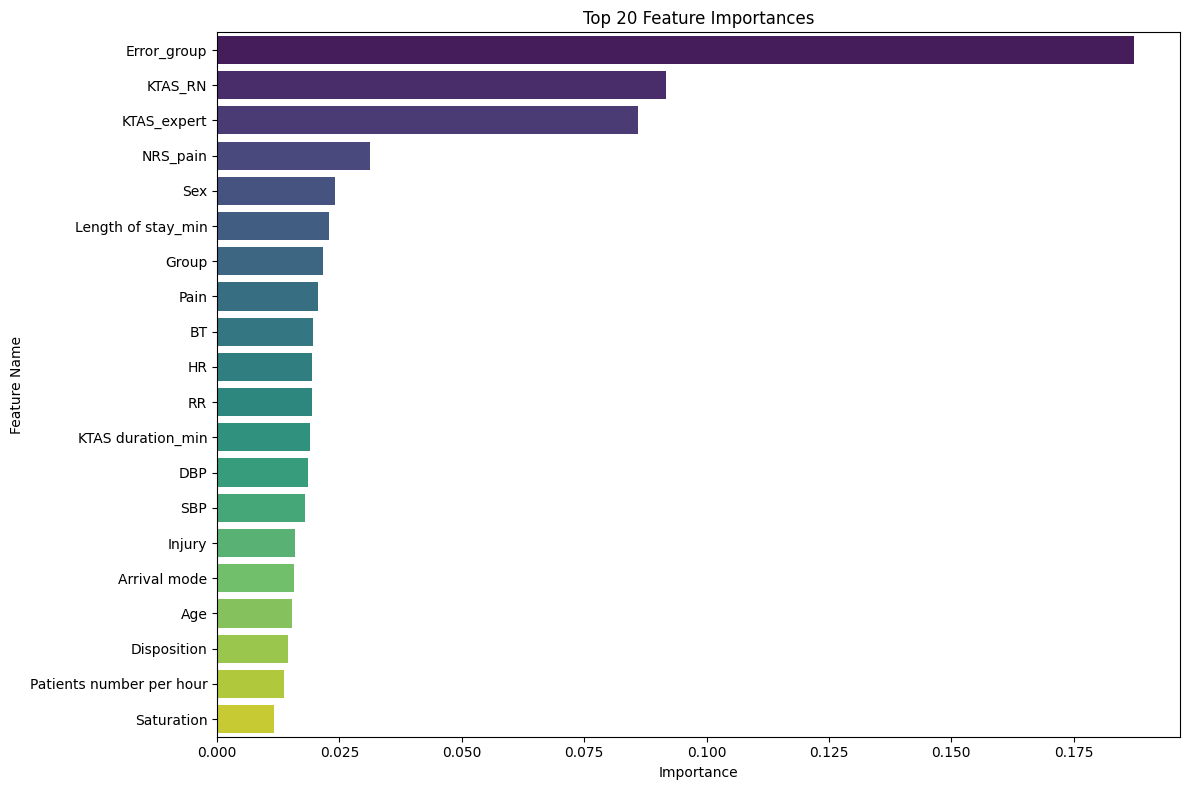

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Get feature names from the preprocessor
# Numerical features names
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical features names after one-hot encoding
categorical_transformer = preprocessor.named_transformers_['cat']
onehot_encoder = categorical_transformer.named_steps['onehot']
categorical_feature_names = onehot_encoder.get_feature_names_out(X.select_dtypes(include=['object']).columns)

# Combine all feature names
all_feature_names = numerical_cols + list(categorical_feature_names)

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Feature Importances:")
display(feature_importance_df.head(20))

# Plotting the top 20 feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis', hue='Feature', legend=False)
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Summary of Attributes in the Prediction Model

**1. Target Variable (`y`):**

*   **`mistriage`**: This column was designated as our target variable. The goal of the model is to predict whether a patient was mistriaged (1 or 2) or correctly triaged (0).

**2. Features (`X`) - Attributes Used for Prediction:**

All other columns from the original dataset, excluding `mistriage`, were used as features to predict the `mistriage` outcome. These features underwent specific preprocessing steps:

*   **Numerical Features**:
    *   `Group`, `Sex`, `Age`, `Patients number per hour`, `Arrival mode`, `Injury`, `Mental`, `Pain`, `KTAS_RN`, `Disposition`, `KTAS_expert`, `Error_group`, `Length of stay_min`, `KTAS duration_min`.
    *   `NRS_pain`, `SBP`, `DBP`, `HR`, `RR`, `BT`, `Saturation`.
    *   **Preprocessing Applied**: For these columns, any non-numeric values (like `#BOÞ!`) were converted to `NaN`, and then all missing numerical values were imputed using the **median** strategy.
    *   **Why**: These are inherently numerical measurements or categorical variables represented numerically. Converting them to a consistent numerical format and handling missing values ensures the model can process them correctly.

*   **Categorical Features (Object Type)**:
    *   `Chief_complain`, `Diagnosis in ED`.
    *   **Preprocessing Applied**: Missing values in these columns were imputed with the constant string 'Missing', and then these columns were **One-Hot Encoded**.
    *   **Why**: These columns contain descriptive text or categories that need to be converted into a numerical format (binary columns for each category) that machine learning models can understand without implying an ordinal relationship where none exists. Imputing with 'Missing' ensures that rows with unknown categories are still included in the analysis and treated as a distinct category.

**3. Attributes Removed/Excluded:**

*   No columns were explicitly *removed* from the feature set. The `mistriage` column was *separated* to serve as the target variable for prediction, not removed from the dataset's consideration, but rather from the set of inputs (`X`).

Value counts for KTAS_RN:


,count
KTAS_RN,
1,18
2,214
3,447
4,501
5,87


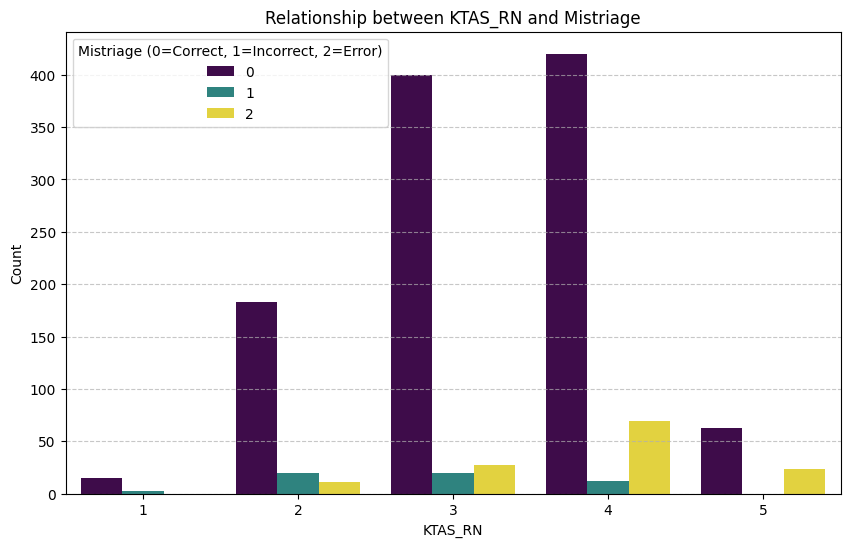

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Value counts for KTAS_RN:")
display(df['KTAS_RN'].value_counts().sort_index())

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='KTAS_RN', hue='mistriage', palette='viridis')
plt.title('Relationship between KTAS_RN and Mistriage')
plt.xlabel('KTAS_RN')
plt.ylabel('Count')
plt.legend(title='Mistriage (0=Correct, 1=Incorrect, 2=Error)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The plot above shows the raw counts. To better understand the *proportion* of mistriage for each `KTAS_RN` level, let's normalize the data and visualize the percentages.

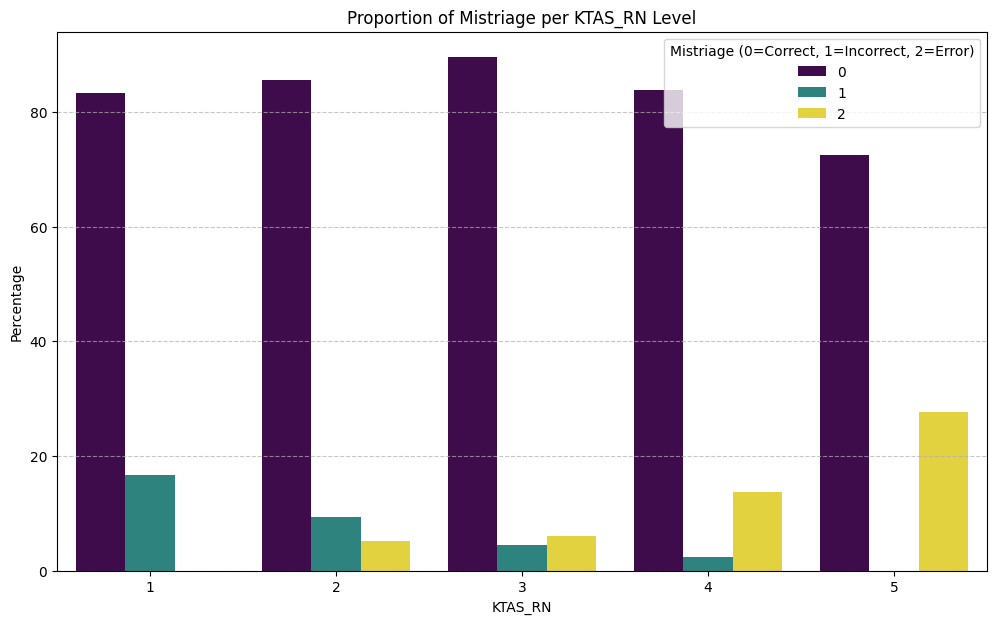

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the proportion of mistriage for each KTAS_RN level
mistriage_proportions = df.groupby('KTAS_RN')['mistriage'].value_counts(normalize=True).mul(100).rename('percentage').reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=mistriage_proportions, x='KTAS_RN', y='percentage', hue='mistriage', palette='viridis')
plt.title('Proportion of Mistriage per KTAS_RN Level')
plt.xlabel('KTAS_RN')
plt.ylabel('Percentage')
plt.legend(title='Mistriage (0=Correct, 1=Incorrect, 2=Error)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Accuracy: 0.9969

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       324
           1       1.00      0.99      1.00       324
           2       1.00      1.00      1.00       325

    accuracy                           1.00       973
   macro avg       1.00      1.00      1.00       973
weighted avg       1.00      1.00      1.00       973


Confusion Matrix:


array([[324,   0,   0],
       [  2, 322,   0],
       [  1,   0, 324]])

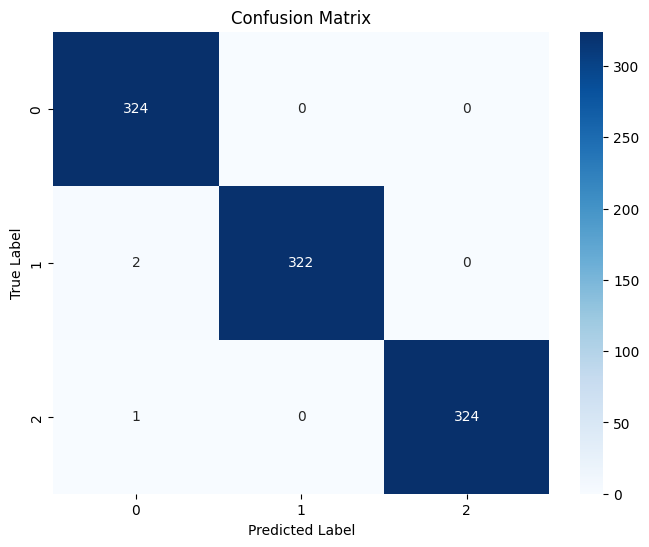

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
display(conf_matrix)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the preprocessed data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_preprocessed, y)

print("Shape of X after SMOTE:", X_resampled.shape)
print("Shape of y after SMOTE:", y_resampled.shape)
print("\nClass distribution of 'mistriage' after SMOTE:")
display(y_resampled.value_counts())

Shape of X after SMOTE: (3243, 1022)
Shape of y after SMOTE: (3243,)

Class distribution of 'mistriage' after SMOTE:


,count
mistriage,
1,1081
2,1081
0,1081


Value Counts for 'mistriage':


,count
mistriage,
0,1081
2,131
1,55



Percentage Distribution for 'mistriage':


,proportion
mistriage,
0,85.319653
2,10.339384
1,4.340963


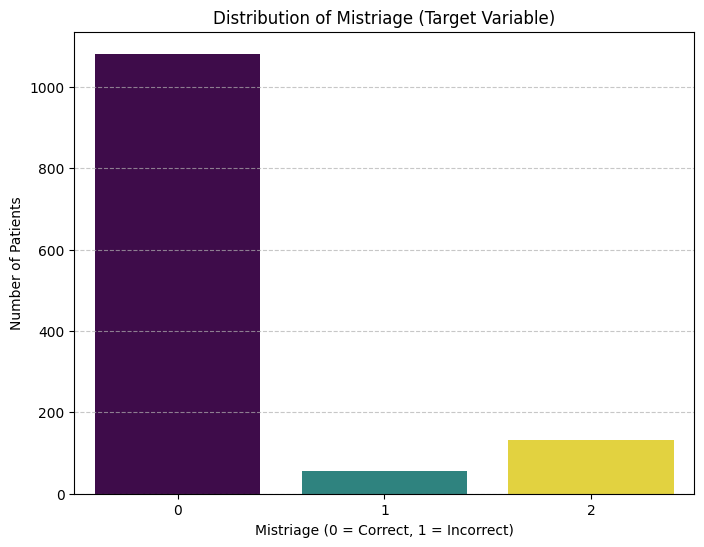

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Value counts and percentage of the target variable 'mistriage'
mistriage_counts = df['mistriage'].value_counts()
mistriage_percentages = df['mistriage'].value_counts(normalize=True) * 100

print("Value Counts for 'mistriage':")
display(mistriage_counts)
print("\nPercentage Distribution for 'mistriage':")
display(mistriage_percentages)

# Plotting the distribution of 'mistriage'
plt.figure(figsize=(8, 6))
sns.barplot(x=mistriage_counts.index, y=mistriage_counts.values, hue=mistriage_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Mistriage (Target Variable)')
plt.xlabel('Mistriage (0 = Correct, 1 = Incorrect)')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np

# Re-download dataset path if not already defined (assuming a fresh kernel or out-of-order execution)
if 'path' not in locals():
    path = kagglehub.dataset_download("ilkeryildiz/emergency-service-triage-application")

# Re-load df if not already defined (assuming a fresh kernel or out-of-order execution)
if 'df' not in locals() or df.empty:
    data_file_path = os.path.join(path, 'data.csv')
    df = pd.read_csv(data_file_path, encoding='latin1', sep=';', decimal=',')

    # Re-apply cleaning steps for vital signs and NRS_pain if df was just loaded
    def clean_and_convert_to_numeric(df, column_name):
        if column_name == 'NRS_pain' and '#BOÞ!' in df[column_name].unique():
            df[column_name] = df[column_name].replace('#BOÞ!', np.nan)

        # Handle potential non-string values before checking unique for '#' in case of prior successful runs
        if column_name == 'NRS_pain' and (df[column_name].apply(lambda x: isinstance(x, str) and '#BOÞ!' in x).any()):
             df[column_name] = df[column_name].replace('#BOÞ!', np.nan)

        df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
        return df

    columns_to_clean = ['NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation']
    for col in columns_to_clean:
        df = clean_and_convert_to_numeric(df, col)

mistriage_missing_count = df['mistriage'].isnull().sum()
mistriage_missing_percentage = (mistriage_missing_count / len(df)) * 100

print(f"Missing values in 'mistriage' column: {mistriage_missing_count}")
print(f"Percentage of missing values in 'mistriage' column: {mistriage_missing_percentage:.2f}%")

Using Colab cache for faster access to the 'emergency-service-triage-application' dataset.
Missing values in 'mistriage' column: 0
Percentage of missing values in 'mistriage' column: 0.00%
